# Stationarity in Quant Finance for Beginners

This notebook explains **stationarity** in a beginner-friendly way and shows how it relates to **normalisation** and other statistical measures used in quant finance.

## What you will learn

- what stationarity means in simple terms
- why raw prices are often non-stationary but returns can be closer to stationary
- how stationarity differs from normalisation
- how stationarity affects mean, variance, covariance, and correlation
- why tests such as ADF are used in time-series modelling

## Beginner intuition

A stationary series behaves in a statistically stable way through time. Its average level, its spread, and its dependence structure do not keep drifting too much. If those properties keep changing, many statistical models become unreliable.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

## 1. What Stationarity Means

A time series is called **stationary** when its statistical properties are stable through time.

### The three main ideas

- **Stable mean**: the series does not drift upward or downward indefinitely
- **Stable variance**: the spread of the series does not keep changing dramatically
- **Stable dependence structure**: relationships across time, such as autocorrelation, do not keep changing unpredictably

### Beginner explanation

A stationary series is easier to model because the “rules of the game” stay more consistent. A non-stationary series keeps changing its behavior, so a model fitted in one period may fail badly in another.

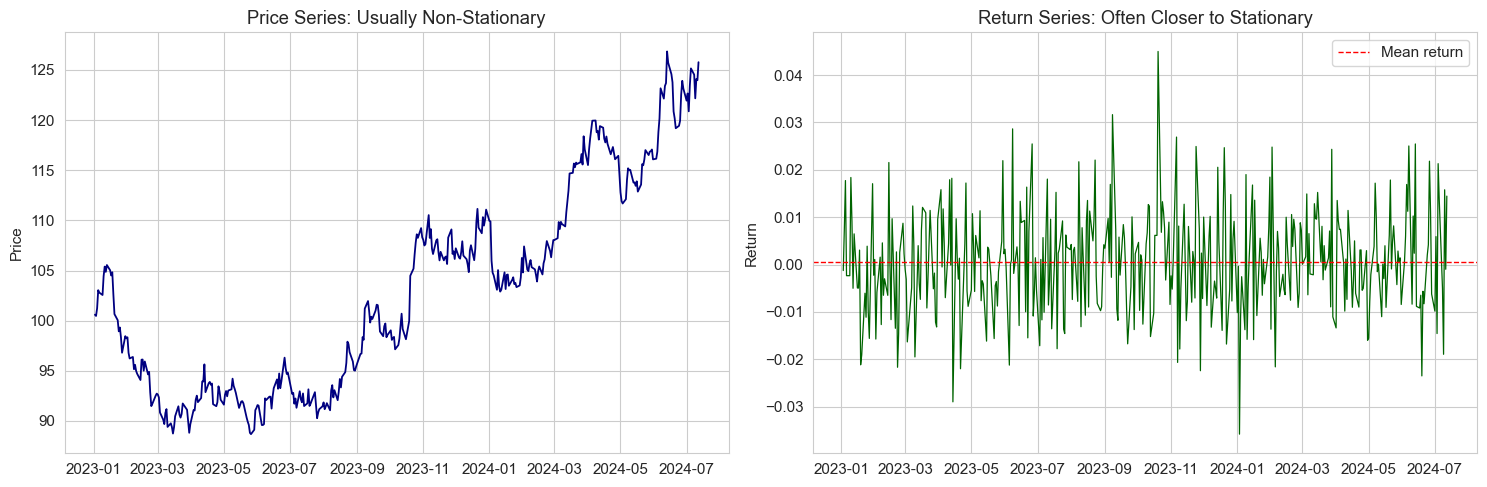

In [2]:
n = 400
dates = pd.bdate_range("2023-01-02", periods=n)

drift = 0.08 / 252
vol = 0.18 / np.sqrt(252)
price_shocks = np.random.normal(drift, vol, n)
log_price = np.cumsum(price_shocks) + np.log(100)
price_series = np.exp(log_price)
return_series = pd.Series(price_series, index=dates).pct_change().dropna()
price_series = pd.Series(price_series, index=dates)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(price_series.index, price_series.values, color="navy", linewidth=1.3)
axes[0].set_title("Price Series: Usually Non-Stationary")
axes[0].set_ylabel("Price")

axes[1].plot(return_series.index, return_series.values, color="darkgreen", linewidth=0.9)
axes[1].axhline(return_series.mean(), color="red", linestyle="--", linewidth=1.0, label="Mean return")
axes[1].set_title("Return Series: Often Closer to Stationary")
axes[1].set_ylabel("Return")
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. Stationarity vs Normalisation

These two ideas are related, but they are **not the same**.

### Normalisation

Normalisation changes the **scale** of the data. Examples include:

- rebasing prices to 100
- min-max scaling to the range 0 to 1
- z-score standardisation

### Stationarity

Stationarity is about the **behavior** of the series through time, not just its scale.

### Beginner explanation

A useful way to think about it is this: normalisation changes **how the data is measured**, while stationarity asks whether the data is **behaving in a stable way over time**.

If you take a stock price that keeps drifting upward and simply rebase it to 100, the chart may look cleaner, but the underlying upward trend is still there. The same is true for min-max scaling or z-score scaling. These methods can make values easier to compare, but they do not automatically remove trend, changing variance, or other time-dependent patterns.

In quant finance, this matters because many models rely on the idea that the future will behave somewhat like the past. If the series keeps changing its average level or its volatility regime, then the model can become unreliable. That is why we often transform prices into returns or differences: not just to rescale them, but to make the process more stable.

Short version: **normalisation helps comparison; stationarity helps modelling.**

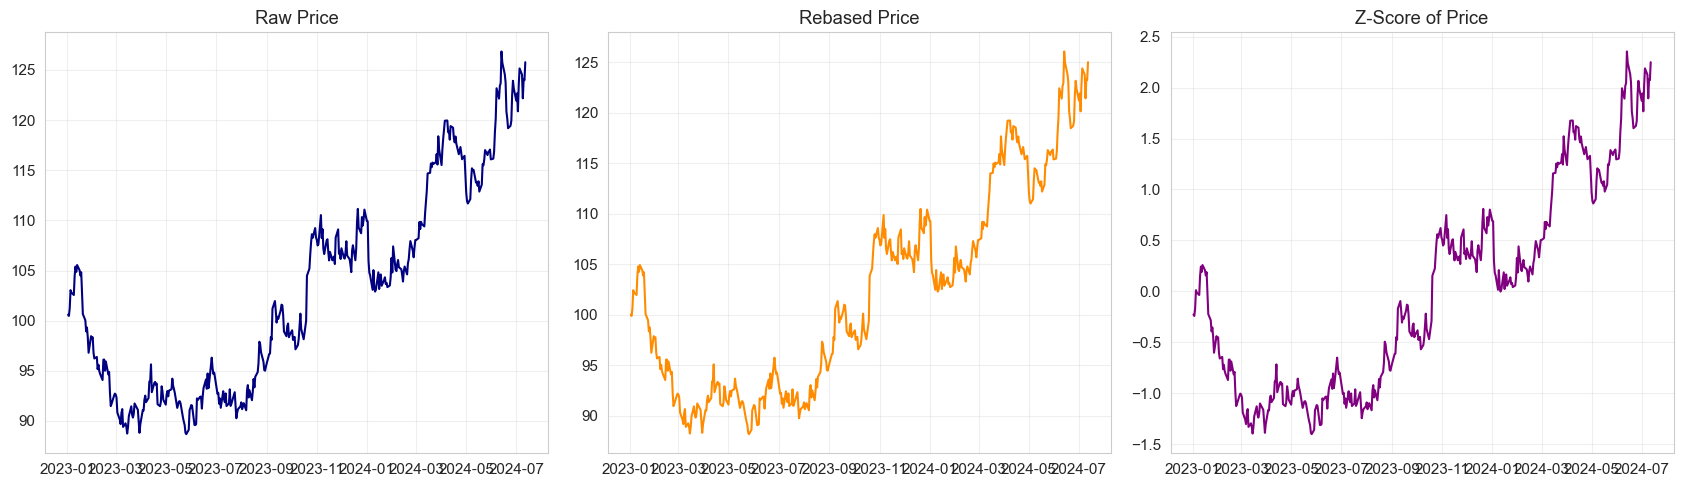

In [3]:
rebased_price = 100 * price_series / price_series.iloc[0]
zscore_price = (price_series - price_series.mean()) / price_series.std(ddof=1)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].plot(price_series.index, price_series.values, color="navy")
axes[0].set_title("Raw Price")

axes[1].plot(rebased_price.index, rebased_price.values, color="darkorange")
axes[1].set_title("Rebased Price")

axes[2].plot(zscore_price.index, zscore_price.values, color="purple")
axes[2].set_title("Z-Score of Price")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Use Cases for Stationarity in Quant Finance

Stationarity matters whenever you want to estimate statistical relationships and expect them to stay meaningful for future periods.

### Common use cases

- **Forecasting models**: AR, ARIMA, and many regression-style time-series models behave better when the input series is stationary
- **Mean-reversion strategies**: z-scores and spread signals are more trustworthy when the underlying spread is stationary
- **Risk estimation**: volatility, covariance, and correlation are easier to estimate when the process is not drifting too much
- **Factor modelling**: stable factor relationships are easier to interpret when the inputs are closer to stationary
- **Hypothesis testing**: many statistical tests assume some degree of stability in the data-generating process

### Beginner explanation

A simple rule is: if you want to use the past to say something about the future, you should care about stationarity. If the process keeps changing, yesterday's statistics may not tell you much about tomorrow.

## 3. Relationship to Other Statistical Measures

Stationarity matters because many common statistics assume the series is reasonably stable.

### Mean

If the mean keeps drifting, the “average” from the past may not describe the future well.

### Variance and volatility

If the variance changes a lot over time, a single volatility estimate can be misleading.

### Covariance and correlation

If co-movement changes over time, covariance and correlation measured in one window may not generalize to another.

### Autocorrelation

Autocorrelation becomes hard to interpret if the basic structure of the series is changing through time.

### Beginner explanation

Stationarity does not mean the data is perfectly flat. It means the statistical quantities you estimate, like average, variance, and correlation, are more meaningful because the process is more stable.

,First Half,Second Half
Mean,-0.000120,0.001354
Variance,0.000112,0.000126
Std Dev,0.010581,0.011218


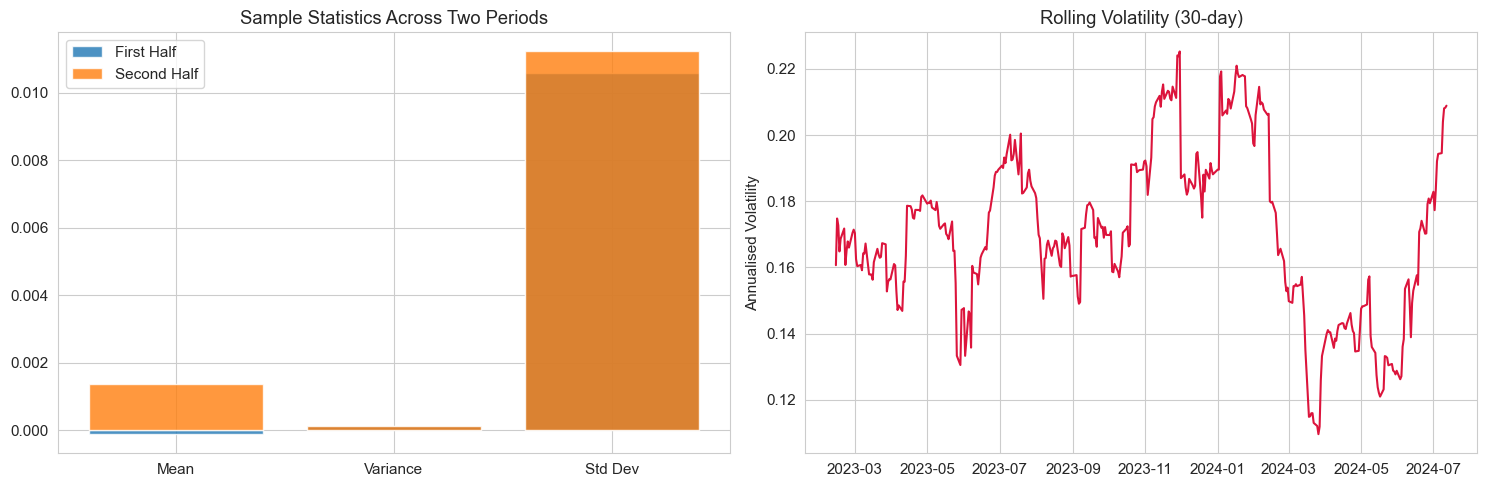

In [4]:
split = len(return_series) // 2

first_half = return_series.iloc[:split]
second_half = return_series.iloc[split:]

stats_compare = pd.DataFrame({
    "First Half": [first_half.mean(), first_half.var(), first_half.std()],
    "Second Half": [second_half.mean(), second_half.var(), second_half.std()],
}, index=["Mean", "Variance", "Std Dev"]).round(6)

display(stats_compare)

rolling_vol = return_series.rolling(30).std() * np.sqrt(252)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(stats_compare.index, stats_compare["First Half"], alpha=0.8, label="First Half")
axes[0].bar(stats_compare.index, stats_compare["Second Half"], alpha=0.8, label="Second Half")
axes[0].set_title("Sample Statistics Across Two Periods")
axes[0].legend()

axes[1].plot(rolling_vol.index, rolling_vol.values, color="crimson")
axes[1].set_title("Rolling Volatility (30-day)")
axes[1].set_ylabel("Annualised Volatility")

plt.tight_layout()
plt.show()

## 4. Testing Stationarity with the Augmented Dickey-Fuller Test

A common statistical test for stationarity is the **ADF test**.

### Basic idea

- **Null hypothesis**: the series has a unit root and is non-stationary
- **Alternative hypothesis**: the series is stationary

### Beginner explanation

A low p-value is usually interpreted as evidence against non-stationarity. In practice, quants often test both prices and returns and find that prices are much less stationary than returns.

In [5]:
def adf_summary(series, name):
    result = adfuller(series.dropna())
    return {
        "Series": name,
        "ADF Statistic": result[0],
        "p-value": result[1],
    }

adf_df = pd.DataFrame([
    adf_summary(price_series, "Price Series"),
    adf_summary(return_series, "Return Series"),
]).set_index("Series").round(6)

display(adf_df)

,ADF Statistic,p-value
Series,,
Price Series,0.016969,0.959913
Return Series,-20.831302,0.000000


## 6. How to Make a Non-Stationary Time Series More Stationary

There is no universal fix, but there are a few standard transformations quants use repeatedly.

### Common approaches

1. **Take returns or differences**
   Price levels often trend, while differences or returns remove part of that trend.

$$\Delta P_t = P_t - P_{t-1}$$

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

2. **Use log differences**
   Log returns are common because they are additive through time and often more stable than raw prices.

$$\Delta \log(P_t) = \log(P_t) - \log(P_{t-1})$$

3. **Detrend the series**
   If the series has a deterministic trend, removing that trend can help.

4. **Stabilize the variance**
   If variance grows with the level, log transforms can sometimes help reduce that effect before differencing.

5. **Use spreads instead of levels**
   In relative-value strategies, a spread between two assets may be more stationary than either asset on its own.

### Beginner explanation

The most common beginner workflow is simple:

- start with prices
- convert them to returns or log returns
- check stationarity again
- only then fit the time-series model

,ADF Statistic,p-value
Series,,
Price Level,0.016969,0.959913
Rebased Price,0.016969,0.959913
First Difference of Price,-20.692927,0.000000
Log Difference / Log Return,-20.833803,0.000000


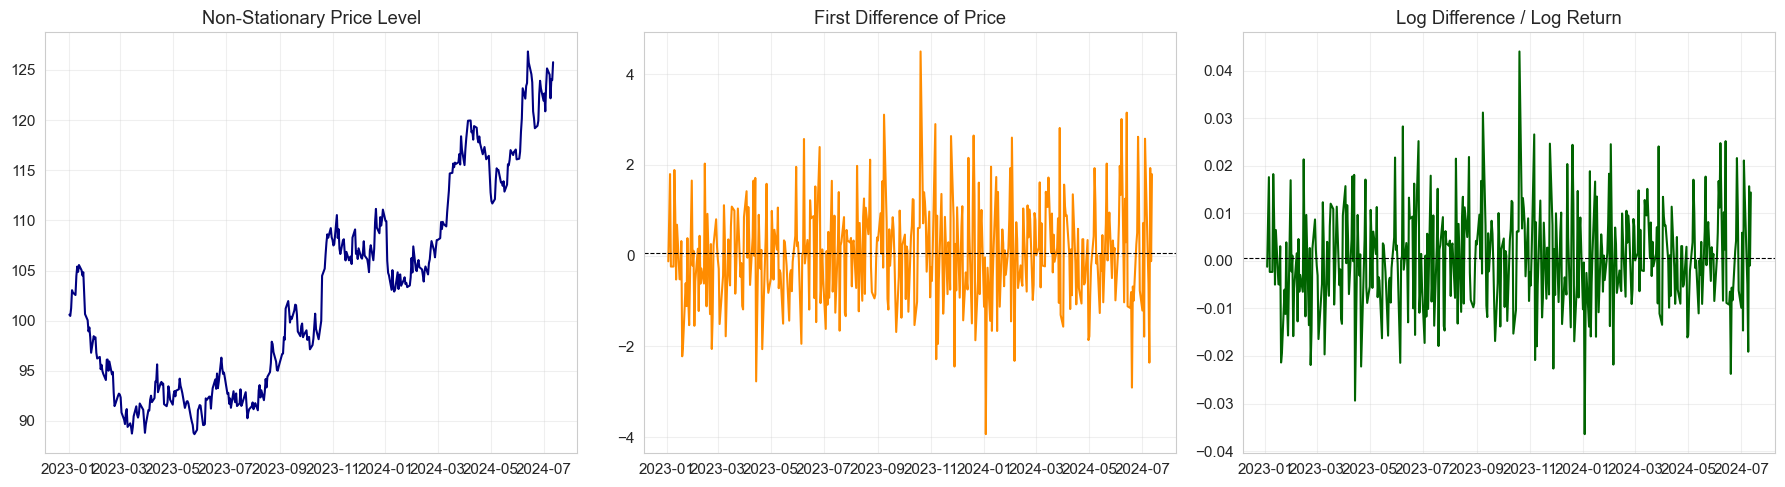

In [6]:
log_price_series = np.log(price_series)
price_diff = price_series.diff().dropna()
log_diff = log_price_series.diff().dropna()

transform_adf_df = pd.DataFrame([
    adf_summary(price_series, "Price Level"),
    adf_summary(rebased_price, "Rebased Price"),
    adf_summary(price_diff, "First Difference of Price"),
    adf_summary(log_diff, "Log Difference / Log Return"),
]).set_index("Series").round(6)

display(transform_adf_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(price_series.index, price_series.values, color="navy")
axes[0].set_title("Non-Stationary Price Level")

axes[1].plot(price_diff.index, price_diff.values, color="darkorange")
axes[1].axhline(price_diff.mean(), color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("First Difference of Price")

axes[2].plot(log_diff.index, log_diff.values, color="darkgreen")
axes[2].axhline(log_diff.mean(), color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Log Difference / Log Return")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Final Takeaways

- Stationarity is about statistical stability through time
- Normalisation changes scale, but does not automatically create stationarity
- Prices are often non-stationary, while returns are often closer to stationary
- Mean, variance, covariance, and autocorrelation are easier to interpret when the series is more stationary
- Stationarity matters because many time-series models assume some degree of stability

### Final beginner takeaway

Normalisation helps you compare data. Stationarity helps you model data. They are related, but they solve different problems. In quant finance, a common workflow is: convert prices to returns, check whether the series is stationary enough, and then apply the statistical model.